In [1]:
%pip install -U imbalanced-learn
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC, SMOTEN
from imblearn.combine import SMOTETomek
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

from sklearn.metrics import fbeta_score,make_scorer
from custom_func import feature_engineering_light, encode_categorical_features,find_best_threshold_f2
from sklearn.model_selection import GridSearchCV, train_test_split,RandomizedSearchCV
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, roc_auc_score, r2_score, mean_squared_error,precision_recall_curve
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')
df_train,df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['y'])
df_train,df_val = train_test_split(df_train, test_size=0.25, random_state=42, stratify=df_train['y'])

In [3]:
# grouping by season, age, grouping education illiterate and unknown in "unknown"
df_train = feature_engineering_light(df_train)
df_val = feature_engineering_light(df_val)
df_test = feature_engineering_light(df_test)

df_train.drop(columns=['duration'],inplace=True)
df_val.drop(columns=['duration'],inplace=True)
df_test.drop(columns=['duration'],inplace=True)

df_train['y'] = df_train['y'].map({'yes': 1, 'no': 0}).astype(int)
df_val['y'] = df_val['y'].map({'yes': 1, 'no': 0}).astype(int)
df_test['y'] = df_test['y'].map({'yes': 1, 'no': 0}).astype(int)

categorical_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
df_train,df_val,df_test,encoded_cols = encode_categorical_features(df_train, df_val, df_test, categorical_cols)

df_train.head()

Drop: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome', 'season', 'age_group']


,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,season_autumn,season_spring,season_summer,season_winter,age_group_Adult,age_group_Child,age_group_Middle Age,age_group_Senior,age_group_Young Adult
7302,23,999,0,1.10,93.99,-36.40,4.86,5191.00,0,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
6693,2,999,0,1.10,93.99,-36.40,4.86,5191.00,0,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
40376,1,0,5,-1.70,94.03,-38.30,0.90,4991.60,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
24387,1,999,0,-0.10,93.20,-42.00,4.19,5195.80,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
33177,1,11,1,-1.80,92.89,-46.20,1.29,5099.10,0,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [4]:
X_train = df_train.drop(columns=['y'])
X_val = df_val.drop(columns=['y'])
X_test = df_test.drop(columns=['y'])


y_train = df_train['y']
y_val = df_val['y']
y_test = df_test['y']


In [5]:
model = DecisionTreeClassifier(random_state=42,max_depth=7, min_samples_leaf=10, min_samples_split=10,class_weight='balanced')
model.fit(X_train, y_train)

print("Depth of the tree:", model.get_depth())

Depth of the tree: 7


In [6]:
prob_val = model.predict_proba(X_val)[:,1]
best_t, best_f2, best_recall, best_precision = find_best_threshold_f2(y_val, prob_val, beta=2)
print("Best threshold:", best_t)
print("F2-score at this threshold:", best_f2)
print("Recall at this threshold:", best_recall)
print("Precision at this threshold:", best_precision)

Best threshold: 0.36122448979591837
F2-score at this threshold: 0.5349605432189393
Recall at this threshold: 0.6282327586206896
Precision at this threshold: 0.335636154289004


In [7]:
# ===== TRAIN =====
prob_train = model.predict_proba(X_train)[:,1]
pred_train_thresh = (prob_train >= best_t).astype(int)  # використання твого threshold

precision_train = precision_score(y_train, pred_train_thresh)
recall_train = recall_score(y_train, pred_train_thresh)
f2_train = fbeta_score(y_train, pred_train_thresh, beta=2)

# ===== VAL =====
prob_val = model.predict_proba(X_val)[:,1]
pred_val_thresh = (prob_val >= best_t).astype(int)

precision_val = precision_score(y_val, pred_val_thresh)
recall_val = recall_score(y_val, pred_val_thresh)
f2_val = fbeta_score(y_val, pred_val_thresh, beta=2)

results = {
    'F2_train_val': f"Train:{round(f2_train,2)} Val:{round(f2_val,2)}",
    'Precision': f"Train:{round(precision_train,2)} Val:{round(precision_val,2)}",
    'Recall': f"Train:{round(recall_train,2)} Val:{round(recall_val,2)}",
    
    'Diff_F2': round(f2_train - f2_val, 2),
    'Diff_Precision': round(precision_train - precision_val, 2),
    'Diff_Recall': round(recall_train - recall_val, 2),
}

results

{'F2_train_val': 'Train:0.55 Val:0.53',
 'Precision': 'Train:0.35 Val:0.34',
 'Recall': 'Train:0.64 Val:0.63',
 'Diff_F2': 0.02,
 'Diff_Precision': 0.01,
 'Diff_Recall': 0.02}

In [8]:

# ===== TEST =====
prob_test = model.predict_proba(X_test)[:,1]
pred_test_thresh = (prob_test >= best_t).astype(int)

precision_test = precision_score(y_test, pred_test_thresh)
recall_test = recall_score(y_test, pred_test_thresh)
f2_test = fbeta_score(y_test, pred_test_thresh, beta=2)


results = {
    'F2_test': f"TEST:{round(f2_test,2)}",
    'Precision': f"TEST:{round(precision_test,2)}",
    'Recall': f"TEST:{round(recall_test,2)}",
}

results

{'F2_test': 'TEST:0.56', 'Precision': 'TEST:0.36', 'Recall': 'TEST:0.65'}

In [9]:
# save model as the best one
import joblib

categorical_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
data_model = {
    'model': model,
    'target_col': 'y',
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols,
    'columns':X_train.columns
}
joblib.dump(data_model, 'bank_model.joblib')

['bank_model.joblib']

In [10]:
import sys
!{sys.executable} -m pip install shap 

Defaulting to user installation because normal site-packages is not writeable


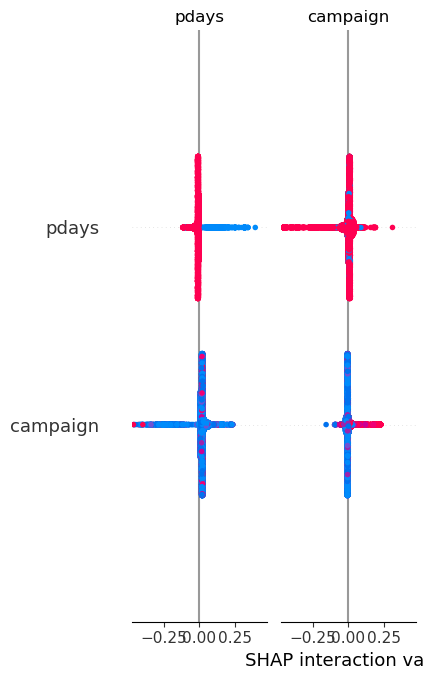

In [11]:
# імпортуємо бібліотеку shap
import shap

shap_values = shap.TreeExplainer(model).shap_values(X_train)  # Обчислення значень SHAP
shap.summary_plot(shap_values, X_train, plot_type="bar")  # Побудова підсумкового графіка SHAP

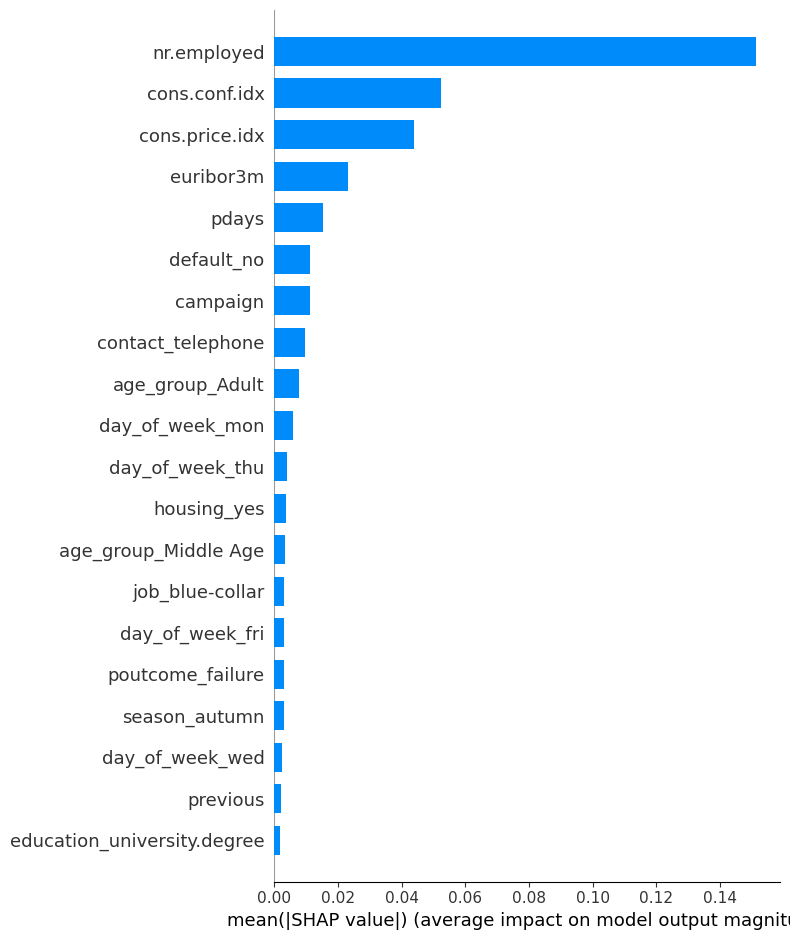

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)  # новий API повертає об'єкт Explanation

# summary plot для всіх ознак класу 1
shap.summary_plot(shap_values.values[:, :, 1], X_train, plot_type="bar")

In [16]:
explainer = shap.KernelExplainer(
    lambda x: model.predict(pd.DataFrame(x, columns=X_train.columns)),
    X_train[:5000]
)

shap_values = explainer.shap_values(X_test[:100])

Using 5000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

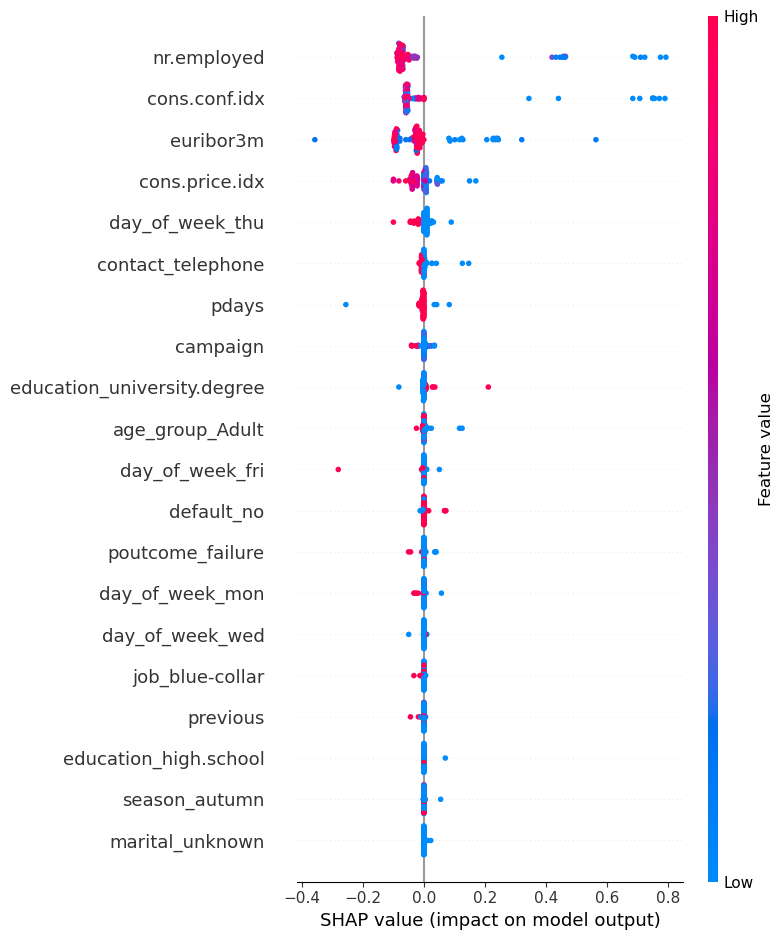

In [17]:
shap.summary_plot(shap_values, X_test[:100])

In [ ]:
# Рядки, де модель помилилась
errors_mask = pred_val_thresh != y_val

# Можна ще подивитися лише на false negatives / false positives
false_negatives = (pred_val_thresh == 0) & (y_val == 1)
false_positives = (pred_val_thresh == 1) & (y_val == 0)

In [ ]:
# Всі помилки
X_val_errors = X_val[errors_mask]
y_val_errors = y_val[errors_mask]

# False negatives
X_val_fn = X_val[false_negatives]
y_val_fn = y_val[false_negatives]

# False positives
X_val_fp = X_val[false_positives]
y_val_fp = y_val[false_positives]

In [ ]:
errors_df = X_val[errors_mask].copy()
errors_df['y_true'] = y_val[errors_mask]
errors_df['y_pred'] = pred_val_thresh[errors_mask]

# Перших 10 помилок
errors_df.head(10)

,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,season_autumn,season_spring,season_summer,season_winter,age_group_Adult,age_group_Child,age_group_Middle Age,age_group_Senior,age_group_Young Adult,y_true,y_pred
39765,1,999,0,-1.80,93.88,-40.00,0.70,5008.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0,1
30729,1,999,0,-1.80,92.89,-46.20,1.34,5099.10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1,0
28945,1,999,0,-1.80,93.08,-47.10,1.41,5099.10,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0,1
39368,1,999,2,-1.80,93.37,-34.80,0.64,5008.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0,1
20036,2,999,0,1.40,93.44,-36.10,4.96,5228.10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1,0
15357,1,999,0,1.40,93.92,-42.70,4.96,5228.10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1,0
7544,15,999,0,1.10,93.99,-36.40,4.86,5191.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1,0
39634,5,999,1,-1.80,93.88,-40.00,0.68,5008.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0,1
35058,1,999,0,-1.80,92.89,-46.20,1.25,5099.10,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0,1
33870,2,999,0,-1.80,92.89,-46.20,1.28,5099.10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0,1


In [ ]:
invalid_mask = (df['pdays'] == 999) &  (df['previous'] > 2)
X_invalid = df[invalid_mask]
print(X_invalid.shape)
X_invalid.head()

(65, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
30079,80,blue-collar,married,high.school,no,no,no,cellular,apr,fri,105,6,999,3,failure,-1.80,93.08,-47.10,1.40,5099.10,no
37240,23,student,single,high.school,no,yes,no,cellular,aug,fri,136,1,999,3,failure,-2.90,92.20,-31.40,0.88,5076.20,no
37353,35,admin.,married,university.degree,no,no,yes,cellular,aug,tue,349,1,999,3,failure,-2.90,92.20,-31.40,0.88,5076.20,yes
37701,66,retired,married,basic.4y,no,yes,yes,telephone,aug,wed,82,3,999,3,failure,-2.90,92.20,-31.40,0.85,5076.20,no
38471,73,retired,divorced,basic.4y,no,yes,no,cellular,oct,mon,127,2,999,3,failure,-3.40,92.43,-26.90,0.73,5017.50,no
